# All Imports

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from torchsummary import summary
import os

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data Loading & Exploration
We use CIFAR-10 (already split into 50k train + 10k test).  
We further split the training set into train (40k) + validation (10k).

Train samples: 40000, Val samples: 10000, Test samples: 10000


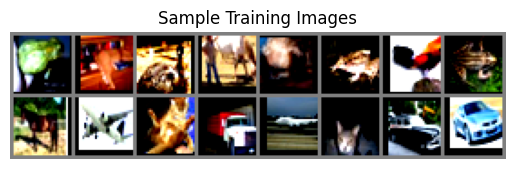

In [34]:
# Transforms
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Datasets
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform_test)

# Split train → train + val (80/20)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# DataLoaders
# DataLoaders - FIXED for clean Colab output
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size,
                         shuffle=True, num_workers=0, pin_memory=True)

val_loader   = DataLoader(val_dataset, batch_size=batch_size,
                         shuffle=False, num_workers=0, pin_memory=True)

test_loader  = DataLoader(test_dataset, batch_size=batch_size,
                         shuffle=False, num_workers=0, pin_memory=True)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")

# Class names
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Show sample images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

dataiter = iter(train_loader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:16]))
plt.title("Sample Training Images")
plt.show()

## Define CNN Architecture

designed a **custom Convolutional Neural Network (CNN)** for multi-class image classification on the CIFAR-10 dataset (10 classes).

### Architecture Highlights:
- **Feature Extractor**: Three convolutional blocks with progressively increasing depth (64 → 128 → 256 channels)
- Each block consists of:
  - Two 3×3 convolutional layers (with padding=1 for spatial preservation)
  - Batch Normalization (optional)
  - ReLU activation
  - 2×2 MaxPooling layer
- **Classifier Head**:
  - Fully connected layer (512 units) with ReLU
  - Dropout (rate = 0.5, optional)
  - Final linear layer to 10 classes

### Two Versions Were Implemented:
1. **With BatchNorm + Dropout** → **Final model** (used for training and evaluation)  
   → Provides better regularization and faster convergence
2. **Without Batch Normalization and Dropout** → For comparison  
   → (For train and compare)

This design clearly demonstrates the impact of regularization techniques on model performance.

**Model Summary (with BatchNorm & Dropout):**

In [35]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=10, use_bn=True, use_dropout=True):
        super().__init__()
        self.use_bn = use_bn
        self.use_dropout = use_dropout

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),   # extra conv layer
            nn.BatchNorm2d(64) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),  # extra conv layer
            nn.BatchNorm2d(128) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),  # extra conv layer
            nn.BatchNorm2d(256) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),   # increased capacity
            nn.ReLU(inplace=True),
            nn.Dropout(0.5) if use_dropout else nn.Identity(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Final model (with BN + Dropout)
model = CustomCNN(use_bn=True, use_dropout=True).to(device)

# Model summary
print("=== Improved Model Architecture with BatchNorm & Dropout ===")
summary(model, (3, 32, 32))

# Optional: version without regularization (for comparison)
model_no_reg = CustomCNN(use_bn=False, use_dropout=False).to(device)
print("\n=== Model WITHOUT regularization ===")
summary(model_no_reg, (3, 32, 32))

=== Improved Model Architecture with BatchNorm & Dropout ===
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          36,928
       BatchNorm2d-5           [-1, 64, 32, 32]             128
              ReLU-6           [-1, 64, 32, 32]               0
         MaxPool2d-7           [-1, 64, 16, 16]               0
            Conv2d-8          [-1, 128, 16, 16]          73,856
       BatchNorm2d-9          [-1, 128, 16, 16]             256
             ReLU-10          [-1, 128, 16, 16]               0
           Conv2d-11          [-1, 128, 16, 16]         147,584
      BatchNorm2d-12          [-1, 128, 16, 16]             256
             ReLU-13          [-1, 128, 16

## 4. Training and Optimization

- **Loss Function**: CrossEntropyLoss (standard for classifying 10 classes)
- **Optimizer**: Adam (learning rate = 0.001) + small weight decay (helps prevent overfitting)
- **Scheduler**: CosineAnnealingLR (automatically lowers the learning rate smoothly)
- **Early Stopping**: Stops training if validation loss doesn’t improve for 10 epochs (saves time)
- Best model is saved automatically as `CNN_result_best.pth`

This setup makes training fast, stable, and stops at the right time.

In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Scheduler (you can keep CosineAnnealing)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)

# Early Stopping Parameters
max_epochs = 100
patience = 10                    # stop if no improvement for 10 epochs
early_stop_counter = 0
best_val_loss = float('inf')

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("Starting training...\n")

for epoch in range(max_epochs):
    # Training Phase
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_losses.append(train_loss / len(train_loader))
    train_accs.append(100. * correct / total)

    # Validation Phase
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(100. * correct / total)

    # Scheduler step
    scheduler.step()

    print(f"Epoch [{epoch+1}/{max_epochs}] | "
          f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.2f}% | "
          f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.2f}%")

    # === Early Stopping Check ===
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        early_stop_counter = 0
        torch.save(model.state_dict(), 'CNN_result_best.pth')   # save best model
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
            break

# Load the best model after training
model.load_state_dict(torch.load('CNN_result_best.pth'))
print(f"\n✅ Training finished. Best model loaded from epoch with lowest val loss.")

Starting training...

Epoch [1/100] | Train Loss: 1.6853 | Train Acc: 37.98% | Val Loss: 1.4267 | Val Acc: 48.36%
Epoch [2/100] | Train Loss: 1.2395 | Train Acc: 55.67% | Val Loss: 1.0955 | Val Acc: 60.42%
Epoch [3/100] | Train Loss: 1.0424 | Train Acc: 63.13% | Val Loss: 0.9874 | Val Acc: 64.51%
Epoch [4/100] | Train Loss: 0.9136 | Train Acc: 67.62% | Val Loss: 1.0513 | Val Acc: 64.48%
Epoch [5/100] | Train Loss: 0.8245 | Train Acc: 71.30% | Val Loss: 0.8952 | Val Acc: 68.80%
Epoch [6/100] | Train Loss: 0.7505 | Train Acc: 74.46% | Val Loss: 0.9412 | Val Acc: 68.53%
Epoch [7/100] | Train Loss: 0.6881 | Train Acc: 76.75% | Val Loss: 0.7255 | Val Acc: 74.58%
Epoch [8/100] | Train Loss: 0.6367 | Train Acc: 78.63% | Val Loss: 0.7005 | Val Acc: 76.40%
Epoch [9/100] | Train Loss: 0.5920 | Train Acc: 80.22% | Val Loss: 0.6472 | Val Acc: 77.97%
Epoch [10/100] | Train Loss: 0.5463 | Train Acc: 81.82% | Val Loss: 0.6146 | Val Acc: 79.26%
Epoch [11/100] | Train Loss: 0.5160 | Train Acc: 82.82% |

# Test Accuracy & validation matrix

Test Accuracy: 87.91%

=== Classification Report ===
              precision    recall  f1-score   support

    airplane     0.9213    0.8190    0.8671      1000
  automobile     0.9344    0.9550    0.9446      1000
        bird     0.8714    0.8130    0.8412      1000
         cat     0.7822    0.7720    0.7771      1000
        deer     0.8987    0.8690    0.8836      1000
         dog     0.8431    0.8220    0.8324      1000
        frog     0.8435    0.9430    0.8905      1000
       horse     0.8899    0.9380    0.9133      1000
        ship     0.8976    0.9380    0.9174      1000
       truck     0.9129    0.9220    0.9174      1000

    accuracy                         0.8791     10000
   macro avg     0.8795    0.8791    0.8785     10000
weighted avg     0.8795    0.8791    0.8785     10000



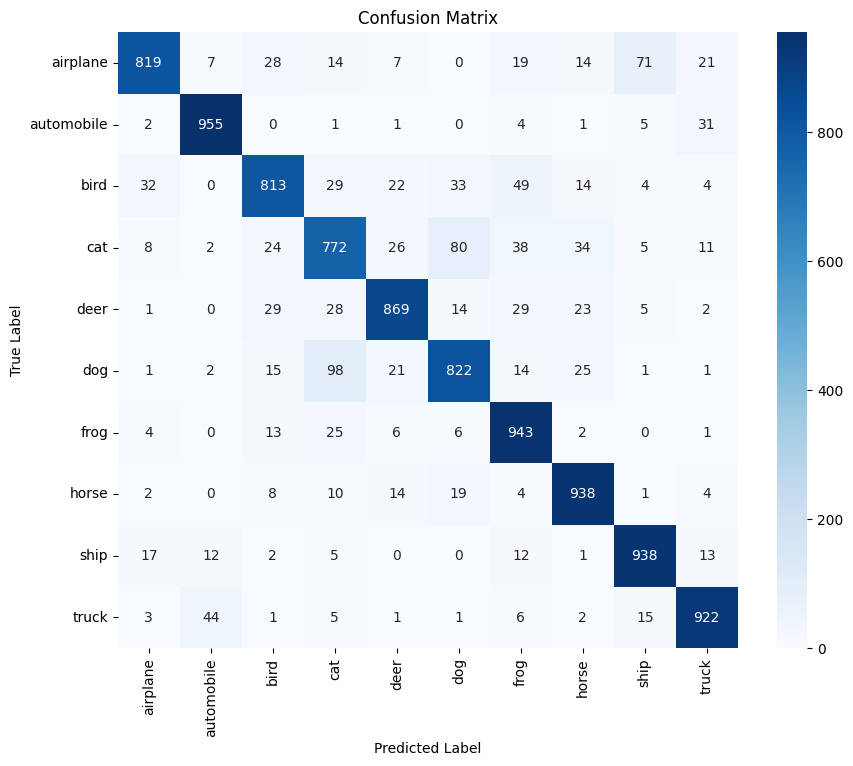


Best performing class : automobile (F1 = 0.9446)
Worst performing class: cat (F1 = 0.7771)


In [38]:

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Test Accuracy
test_acc = 100.0 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"Test Accuracy: {test_acc:.2f}%")

# Classification Report (Precision, Recall, F1)
print("\n=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Per-class Performance
report = classification_report(all_labels, all_preds, target_names=classes, output_dict=True)
f1_scores = {cls: report[cls]['f1-score'] for cls in classes}

best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)

print(f"\nBest performing class : {best_class} (F1 = {f1_scores[best_class]:.4f})")
print(f"Worst performing class: {worst_class} (F1 = {f1_scores[worst_class]:.4f})")

# Visualizations – Loss & Accuracy Curves

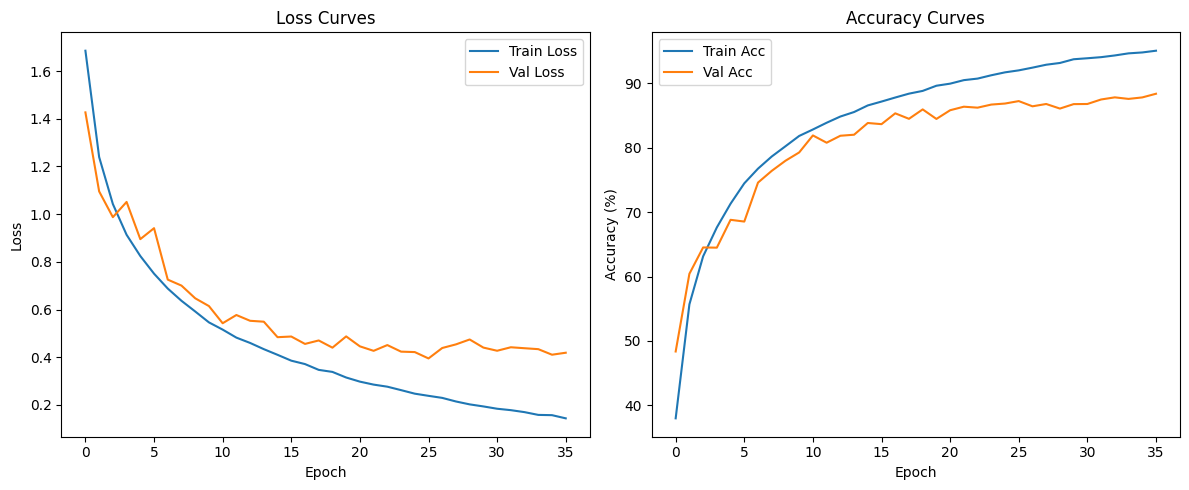

In [37]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()